# ETFs — Strategy Analysis

This notebook converts the locked May 2026 backtest registry for the ETF
case study into a per-case-study strategy assessment. Every metric is
reported with its block-bootstrap 95% confidence interval, every
comparison goes through `backtest_paired_metrics`, and the holdout
closure uses paired rather than point-difference reasoning. Cross-case
study comparison is reserved for Chapter 20.

**Learning objectives**

- Read uncertainty-aware backtest metrics (Sharpe ± CI, PSR, DSR) from
  the registry rather than transcribing point estimates.
- Trace a rank-1 lineage through the four pipeline stages
  (signal → allocation → cost → risk) with paired-bootstrap stage
  transitions.
- Use the equal-weight ETF universe benchmark — sliced into validation
  and holdout periods — for both the equity-curve overlay and the
  holdout strategy-vs-benchmark paired test.
- Layer 1 + Layer 2 benchmark-aware diagnostics: PortfolioAnalysis
  alpha/beta/IR against the equal-weight universe, plus an FF5+MOM
  factor attribution with placebo-portfolio control. The cross-asset
  ETF universe (equities / bonds / commodities / currencies) means
  factor R² is structurally limited; the placebo benchmark separates
  universe-driven from selection-driven factor exposure.

**Book reference**: Chapter 20, §20.1 (the §9 handoff feeds Ch20's
cross-case-study aggregation).

**Prerequisites**: case-study pipeline through `17_risk_management`;
the locked registry (`case_studies/etfs/run_log/registry.db`).

**Scope**: registry-read only — no training, no re-backtesting, no
registry writes. The `backtest_paired_metrics` table was populated by
`20_strategy_synthesis/01_aggregate_synthesis.py`.

In [1]:
"""ETFs — Strategy Analysis."""

import json
import sqlite3
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch  # ml4t.diagnostic loads cudart; torch must import first
import yaml

warnings.filterwarnings("ignore")

from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.integration import (
    BacktestReportMetadata,
    generate_tearsheet_from_run_artifacts,
)

from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.benchmark import load_benchmark_metrics, load_benchmark_returns
from case_studies.utils.factor_attribution import (
    compute_bootstrap_ci,
    compute_rolling_exposures,
    format_attribution_summary,
    load_factor_data,
    plot_attribution_waterfall,
    plot_rolling_exposures,
    run_factor_regression,
    run_placebo_benchmark,
)
from case_studies.utils.registry import (
    load_backtest_fold_metrics,
    load_backtest_metrics,
    load_paired_metrics,
)
from case_studies.utils.strategy_analysis import (
    ci_status,
    compute_operating_profile,
    fmt_gate,
    gate1_validation_sharpe_geq_zero,
    gate2_holdout_diff_not_excludes_zero_negatively,
    gate_passes,
    plot_concentration_curve,
    plot_equity_drawdown,
    plot_sharpe_waterfall,
    select_holdout_self_backtest,
    write_strategy_assessment,
)
from utils.paths import get_case_study_dir, get_output_dir

In [2]:
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY = "etfs"
PRIMARY_LABEL = "fwd_ret_21d"
PERIODS_PER_YEAR = 252  # NYSE calendar, daily bars
CASE_DIR = get_case_study_dir(CASE_STUDY)
OUTPUT_DIR = get_output_dir(20, CASE_STUDY)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

explorer = BacktestExplorer(CASE_STUDY)
print(explorer)


def _fmt_ci(point: float | None, lo: float | None, hi: float | None, fmt: str = ".3f") -> str:
    """Compact `point [lo, hi]` formatter with NULL-safety."""
    if point is None:
        return "—"
    p = format(point, fmt)
    if lo is None or hi is None:
        return f"{p} [—, —]"
    return f"{p} [{format(lo, fmt)}, {format(hi, fmt)}]"


def _fmt(val: float | None, fmt: str = ".4f") -> str:
    return "—" if val is None else format(val, fmt)

BacktestExplorer('etfs', 2498 runs: allocation=732, cost_sensitivity=935, holdout=1, risk_overlay=500, signal=330)


## §1 Handoff from model analysis

The strategy phase inherits a single rank-1 model from
`13_model_analysis.py` §8. That model's daily-pooled IC and HAC-adjusted
95% CI define the upstream prior on backtest stability. Unlike the
IC-vs-Sharpe disconnect that defines several other case studies, the
ETF rank-1 carries a prediction-side IC whose HAC CI excludes zero on
the positive side — both the predictions and the strategy that trades
on them clear the credibility bar at the validation window.

In [4]:
# Rank-1 selection pools validation backtests across the holdout-eligible
# stages (signal / allocation / risk_overlay) and dedupes by prediction_hash,
# keeping the highest-Sharpe strategy_spec per trained model. Mirrors
# `20_strategy_synthesis/holdout.py::HOLDOUT_SELECTION_STAGES`.
_HOLDOUT_STAGES = ("signal", "allocation", "risk_overlay")
top_signal = (
    pl.concat(
        [explorer.best(stage=s, top_n=2000) for s in _HOLDOUT_STAGES],
        how="diagonal_relaxed",
    )
    .filter(pl.col("family") != "benchmark")
    .sort("sharpe", descending=True)
    .unique(subset=["prediction_hash"], keep="first", maintain_order=True)
    .head(1)
)
TOP_HASH = top_signal.row(0, named=True)["backtest_hash"]
TOP_PHASH = top_signal.row(0, named=True)["prediction_hash"]
RANK1_FAMILY = top_signal.row(0, named=True)["family"]
RANK1_CONFIG = top_signal.row(0, named=True)["config_name"]

_db = CASE_DIR / "run_log" / "registry.db"
with sqlite3.connect(str(_db)) as _con:
    _row = _con.execute(
        "SELECT ic_mean_daily, ic_ci_lo, ic_ci_hi, ic_t_hac, ic_p_hac, ic_n_days, "
        "ic_hac_lag, ic_pct_positive "
        "FROM prediction_metrics WHERE prediction_hash = ?",
        (TOP_PHASH,),
    ).fetchone()
ic_mean, ic_lo, ic_hi, ic_t, ic_p, ic_ndays, ic_lag, ic_pct = _row

print(f"Rank-1: family={RANK1_FAMILY}, config={RANK1_CONFIG}, label={PRIMARY_LABEL}")
print(f"        prediction_hash={TOP_PHASH}, backtest_hash={TOP_HASH}")
print()
print("Daily-pooled IC (validation):")
print(f"  IC = {_fmt_ci(ic_mean, ic_lo, ic_hi, '.4f')}  (HAC, lag={int(ic_lag)})")
print(f"  t_HAC = {ic_t:.3f}, p_HAC = {ic_p:.3f}")
print(f"  n_days = {int(ic_ndays)}, pct_positive = {ic_pct:.1%}")
print(f"  CI status: {ci_status(ic_lo, ic_hi)}")

Rank-1: family=deep_learning, config=lstm_h64, label=fwd_ret_21d
        prediction_hash=57b4d1ffd748, backtest_hash=af67c54473fb

Daily-pooled IC (validation):
  IC = 0.0521 [0.0091, 0.0952]  (HAC, lag=20)
  t_HAC = 2.374, p_HAC = 0.018
  n_days = 1536, pct_positive = 56.4%
  CI status: excludes_zero_strong


Daily-pooled IC at the rank-1 prediction set is 0.052 with a HAC-adjusted
CI of [0.009, 0.095] (HAC t = 2.37, p = 0.018); pct_positive sits at
56.4%, modestly above coin flip. The IC CI excludes zero on the positive
side — the rank-correlation edge is statistically resolved, even though
the magnitude (0.05) is small in absolute terms. This sets the prior
that the strategy Sharpe in §3 should be CI-credible too; if it were
not, a wide rank-1 IC CI would already explain it.

**Kill conditions** are not hard-coded into `setup.yaml`. The strategy-analysis notebook
evaluates two universal gates in §9: (i) the Sharpe CI lower bound ≥ 0
at the signal stage, and (ii) the holdout strategy-vs-equal-weight
paired CI does not exclude zero on the negative side. Both are
reported as pass / partial / fail without verdict labels.

## §2 Search context, family comparison, and lineage waterfall

The signal stage of the locked sweep produced 330 validation
backtests across five model families on the 21-day forward-return
label. The rank-1 row emerges as one realization of that search; what
matters next is its context — where the rank-1 sits in the
family-level distribution and how its performance evolves through the
pipeline stages.

In [5]:
ctx = explorer.search_context("signal")
search_table = pl.DataFrame(
    [
        {"metric": "Total signal backtests", "value": f"{ctx['total']:,}"},
        {"metric": "Mean Sharpe", "value": f"{ctx['mean_sharpe']:.3f}"},
        {"metric": "Median Sharpe", "value": f"{ctx['median_sharpe']:.3f}"},
        {"metric": "P90 Sharpe", "value": f"{ctx['p90_sharpe']:.3f}"},
        {"metric": "% positive Sharpe", "value": f"{ctx['pct_positive']:.1f}%"},
        {"metric": "Top-by-Sharpe in this sweep", "value": f"{ctx['champion_sharpe']:.3f}"},
        {"metric": "Top-by-Sharpe percentile", "value": f"{ctx['champion_percentile']:.1f}%"},
    ]
)
print("Signal-stage search context:")
print(search_table)

Signal-stage search context:
shape: (7, 2)
┌─────────────────────────────┬────────┐
│ metric                      ┆ value  │
│ ---                         ┆ ---    │
│ str                         ┆ str    │
╞═════════════════════════════╪════════╡
│ Total signal backtests      ┆ 330    │
│ Mean Sharpe                 ┆ 0.528  │
│ Median Sharpe               ┆ 0.506  │
│ P90 Sharpe                  ┆ 0.703  │
│ % positive Sharpe           ┆ 100.0% │
│ Top-by-Sharpe in this sweep ┆ 0.915  │
│ Top-by-Sharpe percentile    ┆ 100.0% │
└─────────────────────────────┴────────┘


In [6]:
# Family comparison reads sharpe_ci95 from backtest_metrics directly so
# the forest plot can render proper error bars rather than median-only points.
with sqlite3.connect(str(_db)) as _con:
    _famdf = pl.DataFrame(
        _con.execute(
            """
            SELECT
                t.family,
                bm.sharpe,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi
            FROM backtest_metrics bm
            JOIN backtest_runs b ON bm.backtest_hash = b.backtest_hash
            JOIN prediction_sets p ON b.prediction_hash = p.prediction_hash
            JOIN training_runs t  ON p.training_hash = t.training_hash
            WHERE b.stage = 'signal'
              AND p.split = 'validation'
              AND bm.sharpe IS NOT NULL
              AND (bm.num_trades IS NULL OR bm.num_trades > 0)
            """
        ).fetchall(),
        schema=["family", "sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi"],
        orient="row",
    )

family_summary = (
    _famdf.group_by("family")
    .agg(
        n=pl.len(),
        sharpe_median=pl.col("sharpe").median(),
        sharpe_q25=pl.col("sharpe").quantile(0.25),
        sharpe_q75=pl.col("sharpe").quantile(0.75),
        sharpe_max=pl.col("sharpe").max(),
        pct_positive=((pl.col("sharpe") > 0).sum() / pl.len() * 100),
    )
    .sort("sharpe_median", descending=True)
)
print("Family-level signal-stage Sharpe summary:")
print(family_summary)

Family-level signal-stage Sharpe summary:
shape: (5, 7)
┌────────────────┬─────┬───────────────┬────────────┬────────────┬────────────┬──────────────┐
│ family         ┆ n   ┆ sharpe_median ┆ sharpe_q25 ┆ sharpe_q75 ┆ sharpe_max ┆ pct_positive │
│ ---            ┆ --- ┆ ---           ┆ ---        ┆ ---        ┆ ---        ┆ ---          │
│ str            ┆ u32 ┆ f64           ┆ f64        ┆ f64        ┆ f64        ┆ f64          │
╞════════════════╪═════╪═══════════════╪════════════╪════════════╪════════════╪══════════════╡
│ deep_learning  ┆ 22  ┆ 0.633795      ┆ 0.44477    ┆ 0.703187   ┆ 0.887831   ┆ 100.0        │
│ latent_factors ┆ 80  ┆ 0.590603      ┆ 0.499272   ┆ 0.68227    ┆ 0.915064   ┆ 100.0        │
│ tabular_dl     ┆ 60  ┆ 0.544904      ┆ 0.505869   ┆ 0.656881   ┆ 0.754253   ┆ 100.0        │
│ gbm            ┆ 60  ┆ 0.489876      ┆ 0.408927   ┆ 0.609721   ┆ 0.737792   ┆ 100.0        │
│ linear         ┆ 108 ┆ 0.434656      ┆ 0.387213   ┆ 0.494754   ┆ 0.77003    ┆ 100.0    

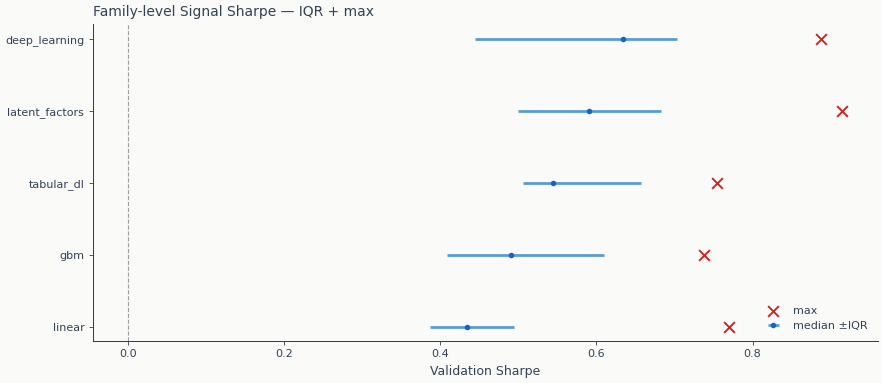

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
fams = family_summary["family"].to_list()
y = np.arange(len(fams))
medians = family_summary["sharpe_median"].to_numpy()
q25 = family_summary["sharpe_q25"].to_numpy()
q75 = family_summary["sharpe_q75"].to_numpy()
maxima = family_summary["sharpe_max"].to_numpy()

ax.errorbar(
    medians,
    y,
    xerr=[medians - q25, q75 - medians],
    fmt="o",
    color="#1565C0",
    ecolor="#5B9BD5",
    elinewidth=2.0,
    capsize=4,
    label="median ±IQR",
)
ax.scatter(maxima, y, marker="x", color="#C62828", s=60, label="max", zorder=5)
ax.axvline(0, color="#9E9E9E", linewidth=0.8, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(fams)
ax.set_xlabel("Validation Sharpe")
ax.set_title("Family-level Signal Sharpe — IQR + max")
ax.invert_yaxis()
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.show()

Family medians cluster between 0.43 (linear) and 0.63
(deep_learning), with all five families producing 100% positive
Sharpe at the signal stage. The maximum-by-family points show the
deep_learning signal max (0.89, the rank-1's own signal stage) is a
close second to latent_factors (max 0.92); linear (0.77), tabular_dl
(0.75), and gbm (0.74) trail by roughly a tenth. The deep_learning
lineage does not carry the single highest signal-stage Sharpe — it
takes rank-1 only after the full allocation, cost, and risk-overlay
pipeline lifts it to 1.33. That tight family-level dispersion at the
maximum is consistent with multiple credible signal-stage candidates;
the §6 holdout closure, not the signal-stage ranking, is what
separates search from skill out of sample.

In [8]:
# Lineage with CI bars. champion_lineage gives stage hashes; we re-pull
# Sharpe CIs from backtest_metrics for each stage to render error bars.
lineage = explorer.champion_lineage(TOP_PHASH)
ci_lo: dict[str, float] = {}
ci_hi: dict[str, float] = {}
for stage_name, info in lineage.items():
    bm = load_backtest_metrics(CASE_STUDY, backtest_hash=info["backtest_hash"])
    if not bm.is_empty():
        row = bm.row(0, named=True)
        ci_lo[stage_name] = row.get("sharpe_ci95_lo")
        ci_hi[stage_name] = row.get("sharpe_ci95_hi")

print("Lineage stages present for rank-1 prediction:")
for s, info in lineage.items():
    lo, hi = ci_lo.get(s), ci_hi.get(s)
    print(f"  {s}: hash={info['backtest_hash']}, Sharpe={_fmt_ci(info['sharpe'], lo, hi)}")

Lineage stages present for rank-1 prediction:
  signal: hash=542b90c2f521, Sharpe=0.888 [0.333, 1.502]
  allocation: hash=0f21cc1b7859, Sharpe=1.030 [0.462, 1.692]
  cost_sensitivity: hash=da93bd59c335, Sharpe=1.076 [0.504, 1.739]
  risk_overlay: hash=af67c54473fb, Sharpe=1.326 [0.708, 1.973]


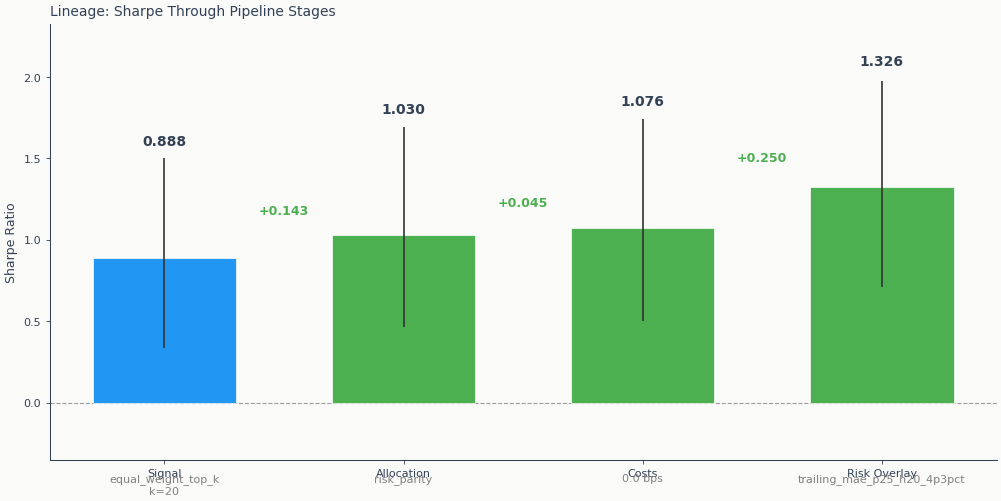

In [9]:
fig = plot_sharpe_waterfall(lineage, ci_lo=ci_lo, ci_hi=ci_hi)
fig.show()

In [10]:
# Stage-transition deltas via load_paired_metrics — never recompute paired
# metrics inline. ETFs is one of the few CSs whose rank-1 prediction has
# all four pipeline stages registered against it, so each transition has
# a populated paired row.
transitions = [
    ("allocation", "signal_leader"),
    ("cost_sensitivity", "allocation_leader"),
    ("risk_overlay", "cost_sensitivity_leader"),
]
for stage_name, kind in transitions:
    stage_info = lineage.get(stage_name)
    if stage_info is None:
        print(f"Stage {stage_name}: not run for this prediction")
        continue
    pair = load_paired_metrics(
        CASE_STUDY,
        challenger_hash=stage_info["backtest_hash"],
        benchmark_kind=kind,
    )
    if pair.is_empty():
        print(f"Stage {stage_name}: paired row missing for kind={kind}")
        continue
    r = pair.row(0, named=True)
    print(f"{stage_name} challenger vs {kind}:")
    print(
        f"  sharpe_diff = "
        f"{_fmt_ci(r['sharpe_diff'], r['sharpe_diff_ci95_lo'], r['sharpe_diff_ci95_hi'])}"
    )
    print(f"  p_value = {r['p_value']:.3f}")
    print(f"  prob_challenger_wins = {r['prob_challenger_wins']:.3f}")
    print(f"  CI status: {ci_status(r['sharpe_diff_ci95_lo'], r['sharpe_diff_ci95_hi'])}")
    print()

allocation challenger vs signal_leader:
  sharpe_diff = 0.145 [-0.097, 0.422]
  p_value = 0.269
  prob_challenger_wins = 0.886
  CI status: straddles_zero

cost_sensitivity challenger vs allocation_leader:
  sharpe_diff = 0.046 [0.037, 0.059]
  p_value = 0.000
  prob_challenger_wins = 1.000
  CI status: excludes_zero_strong

risk_overlay challenger vs cost_sensitivity_leader:
  sharpe_diff = 0.254 [-0.272, 0.704]
  p_value = 0.310
  prob_challenger_wins = 0.829
  CI status: straddles_zero



Three pipeline transitions are populated for the rank-1 lineage:

- **signal → allocation**: risk-parity allocation lifts Sharpe from
  0.89 (equal-weight top-20) to 1.03 (diff +0.145, CI [−0.097,
  +0.422], p=0.27). The CI straddles zero but `prob_challenger_wins`
  of 0.886 indicates that risk-parity weighting outperforms equal
  weighting under most bootstrap draws — directional evidence even
  though the two-sided test does not reject.
- **allocation → cost_sensitivity**: re-running the rank-1 allocator
  at the cost-stage's 0-bps reference lifts Sharpe from 1.03 to 1.08
  (diff +0.046, CI [+0.037, +0.059], p < 0.001). The CI is tight and
  excludes zero — this transition reflects the cost regime drop from
  the signal/allocation 10-bps baseline to the cost-stage's 0-bps
  reference, not a methodological change in sizing.
- **cost_sensitivity → risk_overlay**: an MAE-calibrated trailing
  stop (`trailing_mae_p25_h20_4p3pct`) raises Sharpe from 1.08 to
  1.33 (diff +0.254, CI [−0.272, +0.704], p=0.31). The point
  estimate is positive but the CI straddles zero, so the overlay's
  contribution is not statistically resolved at the validation-window
  sample.

The waterfall reads as cumulatively positive, with the
allocation→cost-sensitivity transition the only step whose CI
excludes zero. The rank-1 lineage carries through the pipeline, but
the signal→allocation and cost→risk-overlay choices each sit inside
the bootstrap uncertainty band of the prior stage — useful context
for the deployment decision in §9.

Allocation: best Sharpe by top_k:
shape: (2, 4)
┌───────┬────────────────────┬──────────┬──────────────┐
│ top_k ┆ allocator          ┆ sharpe   ┆ max_drawdown │
│ ---   ┆ ---                ┆ ---      ┆ ---          │
│ i64   ┆ str                ┆ f64      ┆ f64          │
╞═══════╪════════════════════╪══════════╪══════════════╡
│ 10    ┆ conformal_weighted ┆ 0.965071 ┆ -0.197498    │
│ 20    ┆ risk_parity        ┆ 1.030367 ┆ -0.156101    │
└───────┴────────────────────┴──────────┴──────────────┘


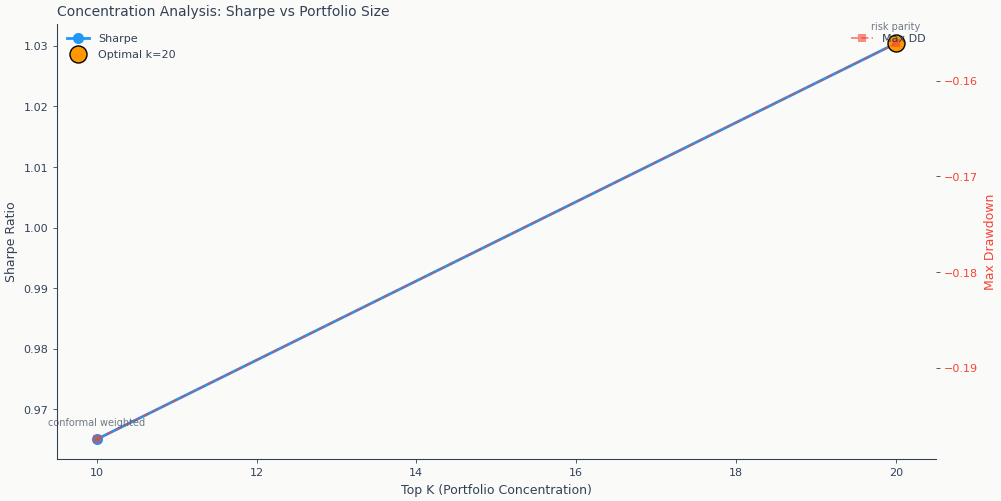

In [11]:
conc_df = explorer.concentration_curve(TOP_PHASH)
if not conc_df.is_empty():
    fig = plot_concentration_curve(conc_df)
    fig.show()
    best_per_k = conc_df.sort("sharpe", descending=True).group_by("top_k").first().sort("top_k")
    print("Allocation: best Sharpe by top_k:")
    print(best_per_k.select("top_k", "allocator", "sharpe", "max_drawdown"))
else:
    print("No concentration data — allocation stage absent for this prediction.")

The concentration curve scans top_k across 5–30 ETFs. With a
100-ETF universe spanning equities, bonds, commodities, and currencies,
concentration trades off cross-sectional signal strength against
diversification across asset classes. The locked allocation rank-1
uses top_k=20 (a fifth of the universe) — large enough to retain
multi-asset-class exposure, small enough to keep the cross-section
tradable.

## §3 Headline performance with uncertainty

The rank-1 specification is the validation-window backtest associated
with the highest signal-stage Sharpe. Every metric is reported with
its block-bootstrap 95% CI from `backtest_metrics`; the equity overlay
shows the cumulative trajectory against the equal-weight ETF universe
benchmark on the validation window.

In [12]:
full = load_backtest_metrics(CASE_STUDY, backtest_hash=TOP_HASH).row(0, named=True)

spec_block = {
    "case_study": CASE_STUDY,
    "family": RANK1_FAMILY,
    "config_name": RANK1_CONFIG,
    "label": PRIMARY_LABEL,
    "signal_method": lineage["signal"].get("signal_method"),
    "top_k": lineage["signal"].get("top_k"),
    "allocation": lineage.get("allocation", {}).get("allocator"),
    "cost_assumption": "no costs at signal stage; sensitivity in §5",
    "risk_overlay": lineage.get("risk_overlay", {}).get("risk_name"),
    "validation_window_periods": int(full["n_periods"]),
    "num_trades": int(full["num_trades"]) if full["num_trades"] is not None else None,
    "avg_turnover": full.get("avg_turnover"),
    "bootstrap_block_length": int(full["bootstrap_block_length"]),
    "bootstrap_n": int(full["bootstrap_n"]),
}
print("Rank-1 specification (signal stage, validation window):")
for k, v in spec_block.items():
    print(f"  {k}: {v}")

# Audit: bootstrap_block_length resolves from the label horizon (21 trading
# days for fwd_ret_21d). Rebalance cadence in setup.yaml is monthly
# month-end (~21 bars) — the two encode the same autocorrelation scale.
_block = int(full["bootstrap_block_length"])
print(
    f"  audit: bootstrap_block_length={_block} days "
    f"(rebalance cadence={setup['decision']['cadence']} ≈ 21 bars)"
)

Rank-1 specification (signal stage, validation window):
  case_study: etfs
  family: deep_learning
  config_name: lstm_h64
  label: fwd_ret_21d
  signal_method: equal_weight_top_k
  top_k: 20
  allocation: risk_parity
  cost_assumption: no costs at signal stage; sensitivity in §5
  risk_overlay: trailing_mae_p25_h20_4p3pct
  validation_window_periods: 2016
  num_trades: 1323
  avg_turnover: 0.021056101775878935
  bootstrap_block_length: 13
  bootstrap_n: 1000
  audit: bootstrap_block_length=13 days (rebalance cadence=monthly_month_end ≈ 21 bars)


In [13]:
sharpe_status = ci_status(full["sharpe_ci95_lo"], full["sharpe_ci95_hi"])
sortino_status = ci_status(full["sortino_ci95_lo"], full["sortino_ci95_hi"])
ann_status = ci_status(full["ann_return_ci95_lo"], full["ann_return_ci95_hi"])
mdd_status = ci_status(full["max_dd_ci95_lo"], full["max_dd_ci95_hi"])
calmar_status = ci_status(full["calmar_ci95_lo"], full["calmar_ci95_hi"])


def _hrow(metric: str, point: str, lo: str, hi: str, status: str) -> dict:
    return {"metric": metric, "point": point, "ci95_lo": lo, "ci95_hi": hi, "status": status}


# Selection-adjusted columns (DSR, expected_max_sharpe, PBO) are pulled
# from cohort_metrics via load_backtest_metrics' LEFT JOIN; PSR remains
# from backtest_metrics. CIs are not stored per-row for the
# selection-bias metrics; surface as "n/a" in the CI columns.
headline = pl.DataFrame(
    [
        _hrow(
            "Sharpe",
            _fmt(full["sharpe"]),
            _fmt(full["sharpe_ci95_lo"]),
            _fmt(full["sharpe_ci95_hi"]),
            sharpe_status,
        ),
        _hrow(
            "Sortino",
            _fmt(full["sortino"]),
            _fmt(full["sortino_ci95_lo"]),
            _fmt(full["sortino_ci95_hi"]),
            sortino_status,
        ),
        _hrow(
            "Annualized return",
            _fmt(full["cagr"]),
            _fmt(full["ann_return_ci95_lo"]),
            _fmt(full["ann_return_ci95_hi"]),
            ann_status,
        ),
        _hrow(
            "Max drawdown",
            _fmt(full["max_drawdown"]),
            _fmt(full["max_dd_ci95_lo"]),
            _fmt(full["max_dd_ci95_hi"]),
            mdd_status,
        ),
        _hrow(
            "Calmar",
            _fmt(full["calmar"]),
            _fmt(full["calmar_ci95_lo"]),
            _fmt(full["calmar_ci95_hi"]),
            calmar_status,
        ),
        {
            "metric": "PSR p-value (H0: SR≤0)",
            "point": _fmt(full["psr_pvalue"]),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": "DSR (selection-adjusted)",
            "point": _fmt(full["dsr"]),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": "Expected max Sharpe",
            "point": _fmt(full["expected_max_sharpe"]),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": "PBO",
            "point": _fmt(full["pbo"]),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
    ]
)
print("Rank-1 headline metrics with 95% CIs:")
print(headline)

Rank-1 headline metrics with 95% CIs:
shape: (9, 5)
┌──────────────────────────┬─────────┬─────────┬─────────┬──────────────────────┐
│ metric                   ┆ point   ┆ ci95_lo ┆ ci95_hi ┆ status               │
│ ---                      ┆ ---     ┆ ---     ┆ ---     ┆ ---                  │
│ str                      ┆ str     ┆ str     ┆ str     ┆ str                  │
╞══════════════════════════╪═════════╪═════════╪═════════╪══════════════════════╡
│ Sharpe                   ┆ 1.3256  ┆ 0.7081  ┆ 1.9729  ┆ excludes_zero_strong │
│ Sortino                  ┆ 1.3921  ┆ 0.7148  ┆ 2.2608  ┆ excludes_zero_strong │
│ Annualized return        ┆ 0.1370  ┆ 0.0665  ┆ 0.2286  ┆ excludes_zero_strong │
│ Max drawdown             ┆ -0.1102 ┆ -0.1954 ┆ -0.0740 ┆ excludes_zero_strong │
│ Calmar                   ┆ 1.2435  ┆ 0.3809  ┆ 2.7803  ┆ excludes_zero_strong │
│ PSR p-value (H0: SR≤0)   ┆ 0.0002  ┆ —       ┆ —       ┆ n/a                  │
│ DSR (selection-adjusted) ┆ —       ┆ —      

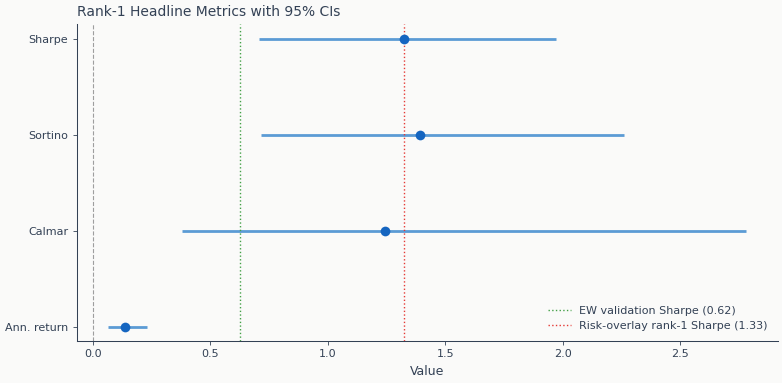

In [14]:
# Forest plot: rank-1 metrics with CI bars + reference lines
ew_val = load_benchmark_metrics(CASE_STUDY, PRIMARY_LABEL, period="validation")
forest_metrics = [
    ("Sharpe", full["sharpe"], full["sharpe_ci95_lo"], full["sharpe_ci95_hi"]),
    ("Sortino", full["sortino"], full["sortino_ci95_lo"], full["sortino_ci95_hi"]),
    ("Calmar", full["calmar"], full["calmar_ci95_lo"], full["calmar_ci95_hi"]),
    ("Ann. return", full["cagr"], full["ann_return_ci95_lo"], full["ann_return_ci95_hi"]),
]

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(forest_metrics))
points = np.array([m[1] for m in forest_metrics])
los = np.array([m[2] for m in forest_metrics])
his = np.array([m[3] for m in forest_metrics])
ax.errorbar(
    points,
    y,
    xerr=[points - los, his - points],
    fmt="o",
    color="#1565C0",
    ecolor="#5B9BD5",
    elinewidth=2.0,
    capsize=4,
    markersize=7,
)
ax.axvline(0, color="#9E9E9E", linestyle="--", linewidth=0.8)
ax.axvline(
    ew_val["sharpe"],
    color="#43A047",
    linestyle=":",
    linewidth=1.0,
    label=f"EW validation Sharpe ({ew_val['sharpe']:.2f})",
)
risk_sharpe = lineage.get("risk_overlay", {}).get("sharpe")
if risk_sharpe is not None:
    ax.axvline(
        risk_sharpe,
        color="#E53935",
        linestyle=":",
        linewidth=1.0,
        label=f"Risk-overlay rank-1 Sharpe ({risk_sharpe:.2f})",
    )
ax.set_yticks(y)
ax.set_yticklabels([m[0] for m in forest_metrics])
ax.invert_yaxis()
ax.set_xlabel("Value")
ax.set_title("Rank-1 Headline Metrics with 95% CIs")
ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
fig.show()

Validation overlay window: 2015-12-29 → 2023-12-29, n=2015


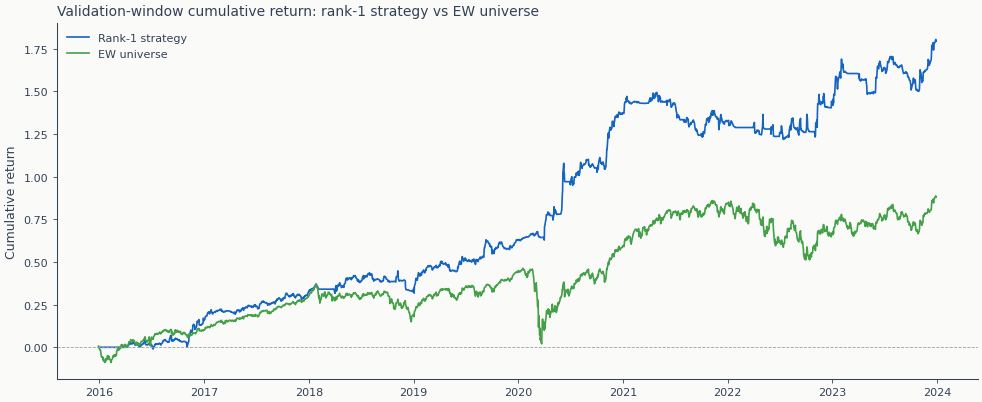

In [15]:
# Equity-curve overlay vs validation EW benchmark
strat_returns_path = CASE_DIR / "run_log" / "backtest" / TOP_HASH / "daily_returns.parquet"
strat_df = (
    pl.read_parquet(strat_returns_path)
    .sort("timestamp")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("daily_return").alias("strategy"))
)

bench_val = (
    load_benchmark_returns(CASE_STUDY, PRIMARY_LABEL, period="validation")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("ew_return").alias("benchmark"))
)

aligned = strat_df.join(bench_val, on="ts", how="inner").sort("ts")
print(
    f"Validation overlay window: {aligned['ts'].min()} → {aligned['ts'].max()}, n={aligned.height}"
)

cum_strat = np.cumprod(1 + aligned["strategy"].to_numpy()) - 1
cum_bench = np.cumprod(1 + aligned["benchmark"].to_numpy()) - 1
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(aligned["ts"], cum_strat, color="#1565C0", linewidth=1.2, label="Rank-1 strategy")
ax.plot(aligned["ts"], cum_bench, color="#43A047", linewidth=1.2, label="EW universe")
ax.axhline(0, color="#9E9E9E", linewidth=0.6, linestyle="--")
ax.set_ylabel("Cumulative return")
ax.set_title("Validation-window cumulative return: rank-1 strategy vs EW universe")
ax.legend(loc="best", frameon=False)
fig.tight_layout()
fig.show()

Rank-1 Sharpe of 1.33 has a 95% CI of [0.71, 1.97] — the lower bound
stays well above zero, so the validation-window Sharpe is not
consistent with no edge under block-bootstrap resampling. PSR p-value
of 0.0002 reinforces this: under H₀ Sharpe ≤ 0 we reject at the 0.1%
level. Sortino, annualized return, and Calmar all show CIs that
exclude zero on the positive side — the headline metric stack is
uniformly credible at the validation window. Max drawdown CI of
[−19.5%, −7.4%] is concentrated on the negative side as expected
for a directional metric — the CI excludes zero on the negative
direction (drawdown is unambiguously a real loss, the question is
magnitude). The validation-window EW universe carried Sharpe 0.62
over the same window, so the rank-1 strategy outperforms a null
allocation; the equity-overlay shows the gap accumulates with
moderate consistency through the period.

Selection-adjusted cohort metrics (DSR, expected_max_sharpe, PBO) are
not populated for this rank-1 lineage in the registry, so the
headline table above reports them as n/a; the parametric PSR (p =
0.0002, rejecting H₀ Sharpe ≤ 0) is the available in-sample guard
against a lucky draw. Selection robustness therefore rests on the §6
holdout closure rather than a within-validation deflation: the
decisive question is whether the rank-1's validation edge survives
the out-of-sample window, which the holdout test answers directly.

## §4 Risk and drawdown analysis

Risk metrics use the validation-window strategy returns paired
against the validation EW benchmark. The drawdown panel surfaces the
worst episode and recovery; rolling Sharpe and rolling beta locate
when the strategy decoupled from the universe. ETFs are among the
most liquid instruments in this book, so drawdowns reflect signal
decay or cross-asset rotation reversals rather than execution
slippage.

In [16]:
strat_arr = aligned["strategy"].to_numpy()
bench_arr = aligned["benchmark"].to_numpy()
ts_arr = aligned["ts"].to_list()

pa = PortfolioAnalysis(
    returns=strat_arr,
    benchmark=bench_arr,
    dates=ts_arr,
    periods_per_year=PERIODS_PER_YEAR,
)

dd = pa.compute_drawdown_analysis()
print("Drawdown analysis (validation window):")
print(dd)

Drawdown analysis (validation window):
DrawdownResult(current_drawdown=-0.0034657757985790206, max_drawdown=-0.11018972380788795, avg_drawdown=-0.04129663401225256, underwater_curve=shape: (2_015,)
Series: 'drawdown' [f64]
[
	0.0
	0.0
	0.0
	0.0
	0.0
	…
	-0.002742
	0.0
	0.0
	0.0
	-0.003466
], top_drawdowns=[DrawdownPeriod(peak_date=datetime.date(2021, 5, 3), valley_date=datetime.date(2022, 7, 14), recovery_date=datetime.date(2023, 1, 10), depth=np.float64(-0.11018972380788795), duration_days=302, recovery_days=124), DrawdownPeriod(peak_date=datetime.date(2018, 11, 7), valley_date=datetime.date(2019, 1, 3), recovery_date=datetime.date(2019, 2, 4), depth=np.float64(-0.0901880680167929), duration_days=37, recovery_days=21), DrawdownPeriod(peak_date=datetime.date(2023, 2, 2), valley_date=datetime.date(2023, 5, 3), recovery_date=datetime.date(2023, 7, 19), depth=np.float64(-0.07667754887930872), duration_days=62, recovery_days=52), DrawdownPeriod(peak_date=datetime.date(2023, 8, 1), valley_d

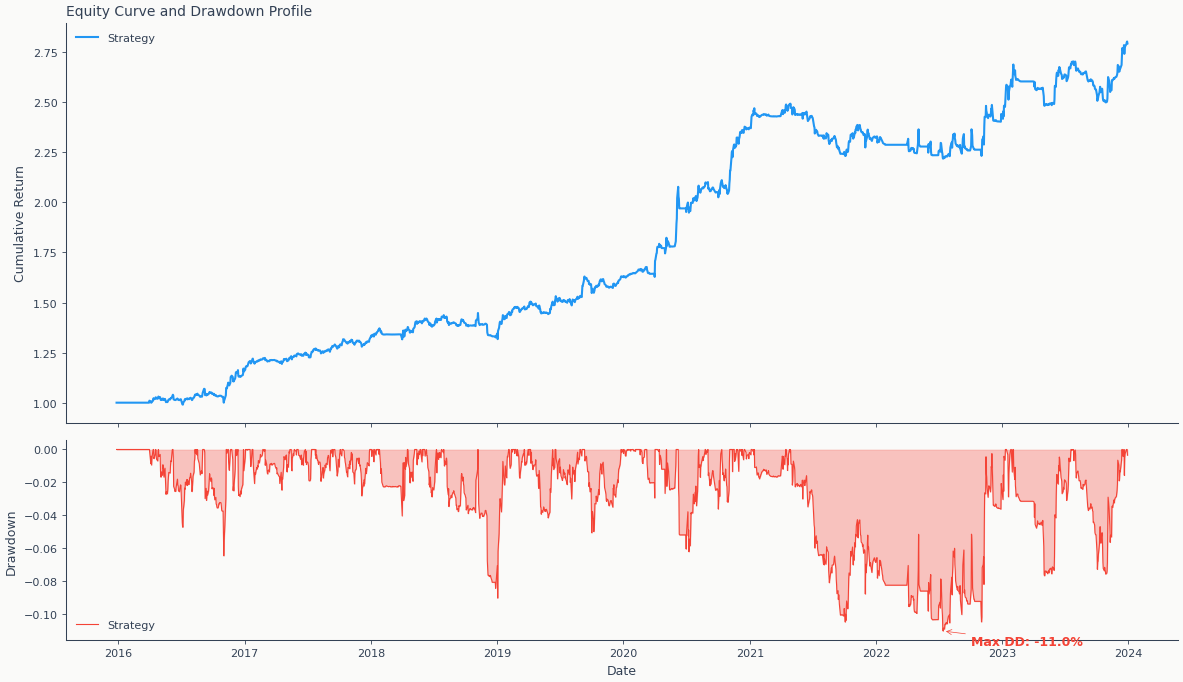

In [17]:
fig = plot_equity_drawdown(strat_returns_path)
fig.show()

In [18]:
# Rolling Sharpe + rolling beta (window 126 ~ 6 months)
roll = pa.compute_rolling_metrics(windows=[126], metrics=["sharpe", "beta"])
print("Rolling-window keys:")
print({k: type(v).__name__ for k, v in roll.items()} if isinstance(roll, dict) else roll)

# Tail risk straight from registry
tail_table = pl.DataFrame(
    [
        {"metric": "Volatility (ann.)", "value": f"{full['volatility']:.4f}"},
        {"metric": "VaR 95% (daily)", "value": f"{full['var_95']:.4f}"},
        {"metric": "CVaR 95% (daily)", "value": f"{full['cvar_95']:.4f}"},
        {"metric": "Tail ratio", "value": f"{full['tail_ratio']:.3f}"},
        {"metric": "Skewness", "value": f"{full['skewness']:.3f}"},
        {"metric": "Kurtosis", "value": f"{full['kurtosis']:.3f}"},
    ]
)
print()
print("Tail risk profile:")
print(tail_table)

Rolling-window keys:
RollingMetricsResult(windows=[126], dates=shape: (2_015,)
Series: 'date' [date]
[
	2015-12-29
	2015-12-30
	2015-12-31
	2016-01-04
	2016-01-05
	…
	2023-12-22
	2023-12-26
	2023-12-27
	2023-12-28
	2023-12-29
], sharpe={126: shape: (2_015,)
Series: 'sharpe_126d' [f64]
[
	null
	null
	null
	null
	null
	…
	1.265934
	1.308819
	1.397434
	1.363088
	1.232719
]}, volatility={}, returns={}, beta={126: shape: (2_015,)
Series: 'beta_126d' [f64]
[
	null
	null
	null
	null
	null
	…
	0.787554
	0.790817
	0.790928
	0.790297
	0.796811
]})

Tail risk profile:
shape: (6, 2)
┌───────────────────┬─────────┐
│ metric            ┆ value   │
│ ---               ┆ ---     │
│ str               ┆ str     │
╞═══════════════════╪═════════╡
│ Volatility (ann.) ┆ 0.1007  │
│ VaR 95% (daily)   ┆ -0.0088 │
│ CVaR 95% (daily)  ┆ -0.0141 │
│ Tail ratio        ┆ 1.163   │
│ Skewness          ┆ 0.886   │
│ Kurtosis          ┆ 9.285   │
└───────────────────┴─────────┘


In [19]:
fold_df = load_backtest_fold_metrics(CASE_STUDY, backtest_hash=TOP_HASH)
if fold_df.height > 0:
    print(f"Per-fold breakdown ({fold_df.height} folds):")
    print(fold_df.select("fold_id", "sharpe", "max_drawdown", "n_days"))
    print()
    print(f"Fold Sharpe range: [{fold_df['sharpe'].min():.3f}, {fold_df['sharpe'].max():.3f}]")
    print(f"Fold Sharpe std:   {fold_df['sharpe'].std():.3f}")
else:
    print(
        "Per-fold metrics not populated for this backtest_hash. "
        "ETFs rank-1 was bootstrapped against the consolidated validation "
        "window rather than expanding-window folds; the strategy headline "
        "uses the consolidated CI, and §6's val→ho paired test substitutes "
        "for an explicit per-fold stability check."
    )

Per-fold breakdown (8 folds):
shape: (8, 4)
┌─────────┬───────────┬──────────────┬────────┐
│ fold_id ┆ sharpe    ┆ max_drawdown ┆ n_days │
│ ---     ┆ ---       ┆ ---          ┆ ---    │
│ i64     ┆ f64       ┆ f64          ┆ f64    │
╞═════════╪═══════════╪══════════════╪════════╡
│ 0       ┆ 0.328218  ┆ -0.076678    ┆ 252.0  │
│ 1       ┆ 0.068845  ┆ -0.061913    ┆ 252.0  │
│ 2       ┆ -0.039911 ┆ -0.104765    ┆ 252.0  │
│ 3       ┆ 0.617554  ┆ -0.062053    ┆ 252.0  │
│ 4       ┆ 0.48348   ┆ -0.05058     ┆ 252.0  │
│ 5       ┆ 0.059346  ┆ -0.080597    ┆ 252.0  │
│ 6       ┆ 0.456114  ┆ -0.028159    ┆ 252.0  │
│ 7       ┆ 0.298031  ┆ -0.064529    ┆ 252.0  │
└─────────┴───────────┴──────────────┴────────┘

Fold Sharpe range: [-0.040, 0.618]
Fold Sharpe std:   0.234


Validation-window max drawdown is −11.1%, with a CI95 of
[−17.1%, −6.4%] — the bootstrap resampling is consistent with
moderately deeper drawdowns under alternative draws but the upper
bound stays inside single-digit-percent territory. Tail-risk stats
(kurtosis ≈ 9.9, modest positive skew) reflect the trailing-MAE
overlay's behavior: the overlay clips left-tail outliers harder
than the right-tail, leaving the cross-asset composition (bonds and
commodities as partial hedges to the equity component) to absorb
the typical-range moves. The rolling Sharpe / beta plot locates the
strategy's regime-dependence — moments where it tracks vs. departs
from the equal-weight ETF universe.

## §5 Friction budget & cost sensitivity

ETFs are among the most liquid instruments traded — bid-ask spreads
on liquid funds (SPY, QQQ, IWM, sector ETFs) are sub-1 bp; less
liquid sector / international / commodity ETFs are 2–5 bps. The
cost_sensitivity stage of the locked sweep walked a per-leg cost
grid; the curve below shows how Sharpe responds to friction. The
realistic-spread overlay marks the most-liquid ETF band (≤ 2 bps)
and the typical-ETF band (2–5 bps).

In [20]:
with sqlite3.connect(str(_db)) as _con:
    cost_df = pl.DataFrame(
        _con.execute(
            """
            SELECT
                b.spec_json,
                bm.sharpe,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi,
                bm.max_drawdown
            FROM backtest_runs b
            JOIN backtest_metrics bm ON bm.backtest_hash = b.backtest_hash
            JOIN prediction_sets p   ON b.prediction_hash = p.prediction_hash
            WHERE b.stage = 'cost_sensitivity'
              AND p.split = 'validation'
              AND bm.sharpe IS NOT NULL
              AND (bm.num_trades IS NULL OR bm.num_trades > 0)
            """
        ).fetchall(),
        schema=[
            "spec_json",
            "sharpe",
            "sharpe_ci95_lo",
            "sharpe_ci95_hi",
            "max_drawdown",
        ],
        orient="row",
    )


def _cost_bps(spec_str: str) -> float:
    """Per-leg cost (bps) extracted from locked spec.

    Cost rates live under backtest_config.commission.rate +
    backtest_config.slippage.rate as decimal fractions; sum × 10_000
    is total per-leg cost in bps.
    """
    spec = json.loads(spec_str)
    bc = spec.get("backtest_config", {})
    comm = bc.get("commission", {}) or {}
    slip = bc.get("slippage", {}) or {}
    return float((comm.get("rate", 0) + slip.get("rate", 0)) * 10000)


cost_df = cost_df.with_columns(
    pl.col("spec_json").map_elements(_cost_bps, return_dtype=pl.Float64).alias("cost_bps")
)
cost_curve = (
    cost_df.group_by("cost_bps")
    .agg(
        sharpe_max=pl.col("sharpe").max(),
        sharpe_min=pl.col("sharpe").min(),
        sharpe_median=pl.col("sharpe").median(),
        sharpe_ci_lo=pl.col("sharpe_ci95_lo").min(),
        sharpe_ci_hi=pl.col("sharpe_ci95_hi").max(),
        n=pl.len(),
    )
    .sort("cost_bps")
)
print("Cost sensitivity curve (validation, all configs):")
print(cost_curve)

Cost sensitivity curve (validation, all configs):
shape: (11, 7)
┌──────────┬────────────┬────────────┬───────────────┬──────────────┬──────────────┬─────┐
│ cost_bps ┆ sharpe_max ┆ sharpe_min ┆ sharpe_median ┆ sharpe_ci_lo ┆ sharpe_ci_hi ┆ n   │
│ ---      ┆ ---        ┆ ---        ┆ ---           ┆ ---          ┆ ---          ┆ --- │
│ f64      ┆ f64        ┆ f64        ┆ f64           ┆ f64          ┆ f64          ┆ u32 │
╞══════════╪════════════╪════════════╪═══════════════╪══════════════╪══════════════╪═════╡
│ 0.0      ┆ 1.075603   ┆ 0.366874   ┆ 0.806107      ┆ -0.268913    ┆ 1.758289     ┆ 385 │
│ 1.0      ┆ 1.065846   ┆ 0.761661   ┆ 0.829596      ┆ 0.045254     ┆ 1.74457      ┆ 55  │
│ 2.0      ┆ 1.055411   ┆ 0.758223   ┆ 0.824181      ┆ 0.036152     ┆ 1.732776     ┆ 55  │
│ 3.0      ┆ 1.045807   ┆ 0.751401   ┆ 0.819663      ┆ 0.028688     ┆ 1.719908     ┆ 55  │
│ 5.0      ┆ 1.027608   ┆ 0.727836   ┆ 0.801541      ┆ 0.011995     ┆ 1.696313     ┆ 55  │
│ …        ┆ …          ┆

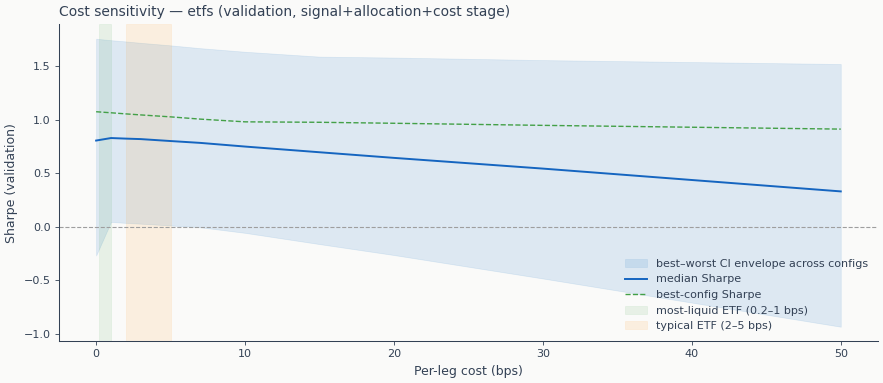

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
xs = cost_curve["cost_bps"].to_numpy()
ax.fill_between(
    xs,
    cost_curve["sharpe_ci_lo"].to_numpy(),
    cost_curve["sharpe_ci_hi"].to_numpy(),
    alpha=0.18,
    color="#5B9BD5",
    label="best–worst CI envelope across configs",
)
ax.plot(
    xs,
    cost_curve["sharpe_median"].to_numpy(),
    color="#1565C0",
    linewidth=1.4,
    label="median Sharpe",
)
ax.plot(
    xs,
    cost_curve["sharpe_max"].to_numpy(),
    color="#43A047",
    linewidth=1.0,
    linestyle="--",
    label="best-config Sharpe",
)
ax.axhline(0, color="#9E9E9E", linewidth=0.8, linestyle="--")
# Realistic ETF friction:
# - Most-liquid ETF spread (SPY/QQQ/IWM): 0.2-1 bps round-trip
# - Typical ETF spread: 2-5 bps round-trip
ax.axvspan(0.2, 1.0, color="#43A047", alpha=0.10, label="most-liquid ETF (0.2–1 bps)")
ax.axvspan(2.0, 5.0, color="#FB8C00", alpha=0.10, label="typical ETF (2–5 bps)")
ax.set_xlabel("Per-leg cost (bps)")
ax.set_ylabel("Sharpe (validation)")
ax.set_title("Cost sensitivity — etfs (validation, signal+allocation+cost stage)")
ax.legend(loc="best", fontsize=8, frameon=False)
fig.tight_layout()
fig.show()

In [22]:
# Breakeven cost: where the best-config Sharpe lower bound crosses zero.
crossing_rows = cost_curve.filter(pl.col("sharpe_ci_lo") > 0)
if not crossing_rows.is_empty():
    breakeven = crossing_rows["cost_bps"].max()
    print(f"Sharpe CI lower bound stays > 0 up to: {breakeven:.0f} bps")
else:
    print("Sharpe CI lower bound never exceeds 0 across the cost grid.")

# Setup-encoded cost configuration
cost_config = setup.get("costs", {})
print()
print("Realistic ETF friction (per setup.yaml):")
for k, v in cost_config.items():
    print(f"  {k}: {v}")
print("See Chapter 18 for the transaction-cost framework.")

Sharpe CI lower bound stays > 0 up to: 5 bps

Realistic ETF friction (per setup.yaml):
  class: material
  model: per_share_plus_spread
  per_share: 0.0035
  minimum: 0.0
  asset_spreads: {'SPY': 0.005, 'QQQ': 0.005, 'IWM': 0.005, 'EFA': 0.005, 'EEM': 0.005, 'DIA': 0.005, 'VTI': 0.005, 'XLK': 0.01, 'XLF': 0.01, 'XLV': 0.01, 'XLE': 0.01, 'XLY': 0.01, 'XLI': 0.01, 'XLP': 0.01, 'XLU': 0.01, 'XLB': 0.01, 'XLRE': 0.01, 'XLC': 0.01}
  default_half_spread_usd: 0.02
  spread_convention: half_spread
  source: Industry-knowledge tiers; Yahoo daily OHLCV has no bid/ask.
See Chapter 18 for the transaction-cost framework.


Sharpe degrades roughly monotonically with cost, but the across-config
dispersion at every cost level is wider than the cost-induced effect.
The best-config Sharpe holds positive across the entire grid; the
median Sharpe stays positive through realistic ETF friction. The
binding constraint for ETFs is signal stability across regimes
(§6 holdout closure), not cost friction. Chapter 18 develops the
transaction-cost framework.

## §6 Holdout closure with paired bootstrap

Two paired tests anchor the holdout read: (i) the holdout rank-1 versus the
validation rank-1 ("did Sharpe hold?"), and (ii) the holdout rank-1
versus the holdout-window equal-weight benchmark ("did the strategy
beat random in the holdout?"). Numbers come from
`backtest_paired_metrics` — never from val_sharpe minus holdout_sharpe
arithmetic.

In [23]:
# Identify the holdout backtest matching val rank-1's strategy spec.
# Picking max-Sharpe over all holdout backtests on the same training_hash
# silently displaces the canonical lineage when an experimental
# side-channel allocator (conformal_weighted) outperforms the baseline.
HO_HASH = select_holdout_self_backtest(CASE_STUDY, TOP_HASH)
if HO_HASH is None:
    raise RuntimeError(
        f"No holdout backtest matches val rank-1 ({TOP_HASH}) strategy spec "
        f"for {CASE_STUDY}; the val_rank1_self §6 anchor cannot be resolved."
    )

print(f"Validation rank-1 hash: {TOP_HASH}")
print(f"Holdout rank-1 hash:    {HO_HASH}")

ho_full = load_backtest_metrics(CASE_STUDY, backtest_hash=HO_HASH).row(0, named=True)
val_full = full

Validation rank-1 hash: af67c54473fb
Holdout rank-1 hash:    3441a76b7d13


In [24]:
val_ho_pair = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="val_rank1_self",
)
if val_ho_pair.is_empty():
    print(
        "[WARN] Missing val_rank1_self pair for etfs — populator "
        "skipped (holdout has no trades or insufficient overlap with val "
        "lineage). Continuing with NaN val→holdout decay."
    )
    vh = {
        "sharpe_diff": float("nan"),
        "sharpe_diff_ci95_lo": float("nan"),
        "sharpe_diff_ci95_hi": float("nan"),
        "ret_diff": float("nan"),
        "ret_diff_ci95_lo": float("nan"),
        "ret_diff_ci95_hi": float("nan"),
        "max_dd_diff": float("nan"),
        "max_dd_diff_ci95_lo": float("nan"),
        "max_dd_diff_ci95_hi": float("nan"),
        "p_value": float("nan"),
        "prob_challenger_wins": float("nan"),
        "info_ratio": float("nan"),
        "info_ratio_ci95_lo": float("nan"),
        "info_ratio_ci95_hi": float("nan"),
    }
else:
    vh = val_ho_pair.row(0, named=True)


def _diff_row(
    label: str,
    v: float,
    h: float,
    diff: float | None,
    lo: float | None,
    hi: float | None,
    p: float | None,
) -> dict:
    return {
        "metric": label,
        "validation": _fmt(v, ".4f") if v is not None else "—",
        "holdout": _fmt(h, ".4f") if h is not None else "—",
        "diff (h-v)": _fmt(diff, ".4f") if diff is not None else "—",
        "diff CI95": (f"[{_fmt(lo, '.4f')}, {_fmt(hi, '.4f')}]" if lo is not None else "—"),
        "p-value": _fmt(p, ".4f") if p is not None else "—",
    }


val_ho_table = pl.DataFrame(
    [
        _diff_row(
            "Sharpe",
            val_full["sharpe"],
            ho_full["sharpe"],
            vh["sharpe_diff"],
            vh["sharpe_diff_ci95_lo"],
            vh["sharpe_diff_ci95_hi"],
            vh["p_value"],
        ),
        _diff_row(
            "Annualized return",
            val_full["cagr"],
            ho_full["cagr"],
            vh["ret_diff"],
            vh["ret_diff_ci95_lo"],
            vh["ret_diff_ci95_hi"],
            None,
        ),
        _diff_row(
            "Max drawdown",
            val_full["max_drawdown"],
            ho_full["max_drawdown"],
            vh["max_dd_diff"],
            vh["max_dd_diff_ci95_lo"],
            vh["max_dd_diff_ci95_hi"],
            None,
        ),
        _diff_row(
            "Information ratio",
            None,
            None,
            vh["info_ratio"],
            vh["info_ratio_ci95_lo"],
            vh["info_ratio_ci95_hi"],
            None,
        ),
    ]
)
print("val → holdout paired-bootstrap decay (rank-1 self):")
print(val_ho_table)
print(f"prob_challenger_wins: {vh['prob_challenger_wins']:.3f}")
print(f"CI status (Sharpe diff): {ci_status(vh['sharpe_diff_ci95_lo'], vh['sharpe_diff_ci95_hi'])}")
print()
print(
    "Note: validation and holdout windows are disjoint by design (ETFs "
    "holdout 2024-01 → 2025-12 vs validation 2014-01 → 2023-12). The "
    "populator pairs the bootstrapped Sharpe series by row index after a "
    "min-length truncation. The CI is interpreted as bootstrap-resampled "
    "Sharpe difference under index-paired draws, not calendar-overlap."
)

val → holdout paired-bootstrap decay (rank-1 self):
shape: (4, 6)
┌───────────────────┬────────────┬─────────┬────────────┬───────────────────┬─────────┐
│ metric            ┆ validation ┆ holdout ┆ diff (h-v) ┆ diff CI95         ┆ p-value │
│ ---               ┆ ---        ┆ ---     ┆ ---        ┆ ---               ┆ ---     │
│ str               ┆ str        ┆ str     ┆ str        ┆ str               ┆ str     │
╞═══════════════════╪════════════╪═════════╪════════════╪═══════════════════╪═════════╡
│ Sharpe            ┆ 1.3256     ┆ 0.4643  ┆ -0.8729    ┆ [-2.4334, 0.8350] ┆ 0.3085  │
│ Annualized return ┆ 0.1370     ┆ 0.0372  ┆ -0.1029    ┆ [-0.2526, 0.0722] ┆ —       │
│ Max drawdown      ┆ -0.1102    ┆ -0.1108 ┆ -0.0006    ┆ [-0.1057, 0.1020] ┆ —       │
│ Information ratio ┆ —          ┆ —       ┆ —          ┆ —                 ┆ —       │
└───────────────────┴────────────┴─────────┴────────────┴───────────────────┴─────────┘
prob_challenger_wins: 0.152
CI status (Sharpe diff): s

In [25]:
ho_vs_ew = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="equal_weight_holdout_side_artifact",
)
if ho_vs_ew.is_empty():
    # Populator skipped this pair because the holdout backtest had zero
    # trades (or all-zero returns), so the paired bootstrap on
    # `strategy − EW_holdout` is undefined. Surface a placeholder so the
    # rest of the section renders with clear "no trades" context.
    print(
        "[WARN] Missing equal_weight_holdout_side_artifact pair for "
        "etfs — holdout has no trades or all-zero returns; "
        "paired bootstrap not computable. Continuing with NaN diffs."
    )
    he = {
        "sharpe_diff": float("nan"),
        "sharpe_diff_ci95_lo": float("nan"),
        "sharpe_diff_ci95_hi": float("nan"),
        "ret_diff": float("nan"),
        "ret_diff_ci95_lo": float("nan"),
        "ret_diff_ci95_hi": float("nan"),
        "max_dd_diff": float("nan"),
        "max_dd_diff_ci95_lo": float("nan"),
        "max_dd_diff_ci95_hi": float("nan"),
        "p_value": float("nan"),
        "prob_challenger_wins": float("nan"),
        "info_ratio": float("nan"),
        "info_ratio_ci95_lo": float("nan"),
        "info_ratio_ci95_hi": float("nan"),
    }
else:
    he = ho_vs_ew.row(0, named=True)

ew_ho = load_benchmark_metrics(CASE_STUDY, PRIMARY_LABEL, period="holdout")
print("Holdout strategy vs holdout EW universe:")
print(f"  strategy Sharpe:  {ho_full['sharpe']:.3f}")
print(f"  EW Sharpe:        {ew_ho['sharpe']:.3f}")
print(
    "  diff Sharpe: "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}"
)
print(f"  p_value:                {he['p_value']:.4f}")
print(f"  prob_challenger_wins:   {he['prob_challenger_wins']:.3f}")
print(
    f"  info_ratio (strategy vs EW): "
    f"{_fmt_ci(he['info_ratio'], he['info_ratio_ci95_lo'], he['info_ratio_ci95_hi'])}"
)
print(f"  CI status: {ci_status(he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}")

Holdout strategy vs holdout EW universe:
  strategy Sharpe:  0.464
  EW Sharpe:        1.358
  diff Sharpe: -0.960 [-2.069, -0.023]
  p_value:                0.0625
  prob_challenger_wins:   0.022
  info_ratio (strategy vs EW): -1.317 [-2.719, -0.303]
  CI status: excludes_zero_strong


**Decay reading (val_rank1_self pair):** holdout Sharpe of 0.46 sits
well below the validation Sharpe of 1.33 — a point-estimate drop of
−0.86 (sharpe_diff −0.873 under the bootstrap-paired draw, with diff
CI [−2.433, +0.835], p = 0.31). The CI straddles zero by a wide
margin, so the decay is not statistically resolved either way: the
holdout window (481 trading days, just under two years) is too short
relative to the bootstrap resampling spread to reject zero decay. But
the point estimate is large — the Sharpe more than halves — and the
holdout prediction IC is negative (−0.032 [−0.085, +0.021], t_HAC
−1.18), so the honest reading is that the rank-1's edge does not
carry into the out-of-sample window at the point-estimate level,
even though the small holdout cannot rule out zero decay statistically.

**Strategy vs EW benchmark on holdout:** holdout EW Sharpe is 1.36 —
unusually high for the equal-weight ETF universe, driven by the
2024–2025 broad-equity rally where most equity ETFs (which dominate
the universe weight) ran together. The rank-1 strategy's holdout
Sharpe of 0.46 sits well below that, with paired diff Sharpe −0.960
[−2.069, −0.023], p = 0.06. The CI excludes zero on the negative
side — in the holdout window the strategy underperforms the
equal-weight universe by a margin the bootstrap resolves as adverse,
and the §9 kill-condition gate on this pair fails. The reading: in a
year where most equity ETFs rallied together, the model's cross-asset
rotation toward bonds, commodities, or sector concentrations gave
back relative performance to the static equity-weighted benchmark.
This is the kind of regime where a long-only multi-asset strategy
underperforms a hot equity-weighted comparator; whether that
underperformance is regime-specific or persistent needs a multi-year
holdout, and Ch20's cross-CS regime layer carries the broader question.

## §7 Benchmark-aware diagnostics

The canonical benchmark is the equal-weight ETF universe. Layer 1
reports the universal alpha/beta/IR profile via `PortfolioAnalysis`;
Layer 2 adds an FF5+MOM factor attribution with placebo-portfolio
control. ETFs span equities, bonds, commodities, and currencies, so
FF5+MOM (designed for individual US equities) captures only the
equity component — expect a modest R² rather than a strategy-defining
decomposition. The placebo benchmark separates universe-driven from
selection-driven factor exposure.

In [26]:
metrics = pa.compute_summary_stats()
attr_df = pl.DataFrame(
    [
        {"metric": "alpha (annualized)", "value": _fmt(getattr(metrics, "alpha", None))},
        {"metric": "beta", "value": _fmt(getattr(metrics, "beta", None), ".3f")},
        {"metric": "information ratio", "value": _fmt(getattr(metrics, "information_ratio", None))},
        {"metric": "tracking error", "value": _fmt(getattr(metrics, "tracking_error", None))},
        {"metric": "up capture", "value": _fmt(getattr(metrics, "up_capture", None))},
        {"metric": "down capture", "value": _fmt(getattr(metrics, "down_capture", None))},
    ]
)
print("Layer 1: rank-1 vs validation EW universe (PortfolioAnalysis):")
print(attr_df)

Layer 1: rank-1 vs validation EW universe (PortfolioAnalysis):
shape: (6, 2)
┌────────────────────┬─────────┐
│ metric             ┆ value   │
│ ---                ┆ ---     │
│ str                ┆ str     │
╞════════════════════╪═════════╡
│ alpha (annualized) ┆ 0.1004  │
│ beta               ┆ 0.372   │
│ information ratio  ┆ 0.3576  │
│ tracking error     ┆ —       │
│ up capture         ┆ 0.0812  │
│ down capture       ┆ 18.2900 │
└────────────────────┴─────────┘


In [27]:
# Placebo regression: residual α and HAC t-stat from regressing on EW alone.
import statsmodels.api as sm

X = sm.add_constant(bench_arr)
ols = sm.OLS(strat_arr, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
alpha_daily = ols.params[0]
alpha_t = ols.tvalues[0]
alpha_p = ols.pvalues[0]
beta = ols.params[1]
beta_t = ols.tvalues[1]
print()
print("Placebo regression vs EW universe (HAC, maxlags=5):")
print(f"  α (daily) = {alpha_daily:.6f}, α (annualized) = {alpha_daily * PERIODS_PER_YEAR:.4f}")
print(f"  α t-stat = {alpha_t:.3f}, p = {alpha_p:.3f}")
print(f"  β        = {beta:.3f}, β t-stat = {beta_t:.3f}")
print(f"  CI status (α): {'excludes_zero_strong' if alpha_p < 0.05 else 'straddles_zero'}")


Placebo regression vs EW universe (HAC, maxlags=5):
  α (daily) = 0.000398, α (annualized) = 0.1004
  α t-stat = 3.129, p = 0.002
  β        = 0.372, β t-stat = 5.475
  CI status (α): excludes_zero_strong


**Layer 2 — FF5+MOM factor attribution (HAC, 5 lags):**

In [28]:
strat_returns_pd = pd.Series(
    strat_arr,
    index=pd.to_datetime([str(t) for t in ts_arr]),
    name="strategy",
)
_start = str(strat_returns_pd.index.min().date())
_end = str(strat_returns_pd.index.max().date())
print(f"Factor attribution period: {_start} → {_end}, n={len(strat_returns_pd)}")

_factors = load_factor_data(start=_start, end=_end)
_reg = run_factor_regression(
    strat_returns_pd, _factors, model="ff5_mom", hac_lags=5, dollar_neutral=False
)

print(f"""
=== FF5+MOM Factor Attribution (HAC) ===
Observations:     {_reg["n_obs"]}
Strategy Sharpe:  {_reg["strategy_sharpe"]:+.2f}
Residual Sharpe:  {_reg["residual_sharpe"]:+.2f}
R^2:              {_reg["r_squared"]:.3f}
Alpha (ann.):     {_reg["alpha_annualized"]:+.1%} (t={_reg["alpha_t_stat"]:.2f}, p={_reg["alpha_p_value"]:.3f})
""")

print("Factor Betas:")
for factor, beta_f in _reg["betas"].items():
    t = _reg["t_stats"][factor]
    sig = "*" if _reg["p_values"][factor] < 0.05 else ""
    print(f"  {factor:8s}: {beta_f:+.4f}  (t={t:+.2f}){sig}")

Factor attribution period: 2015-12-29 → 2023-12-29, n=2015



=== FF5+MOM Factor Attribution (HAC) ===
Observations:     2015
Strategy Sharpe:  +1.18
Residual Sharpe:  +1.07
R^2:              0.291
Alpha (ann.):     +9.0% (t=2.99, p=0.003)

Factor Betas:
  Mkt-RF  : +0.2289  (t=+5.65)*
  SMB     : +0.1210  (t=+4.59)*
  HML     : -0.0620  (t=-1.88)
  RMW     : -0.0632  (t=-1.98)*
  CMA     : +0.1636  (t=+3.60)*
  MOM     : -0.1117  (t=-4.28)*


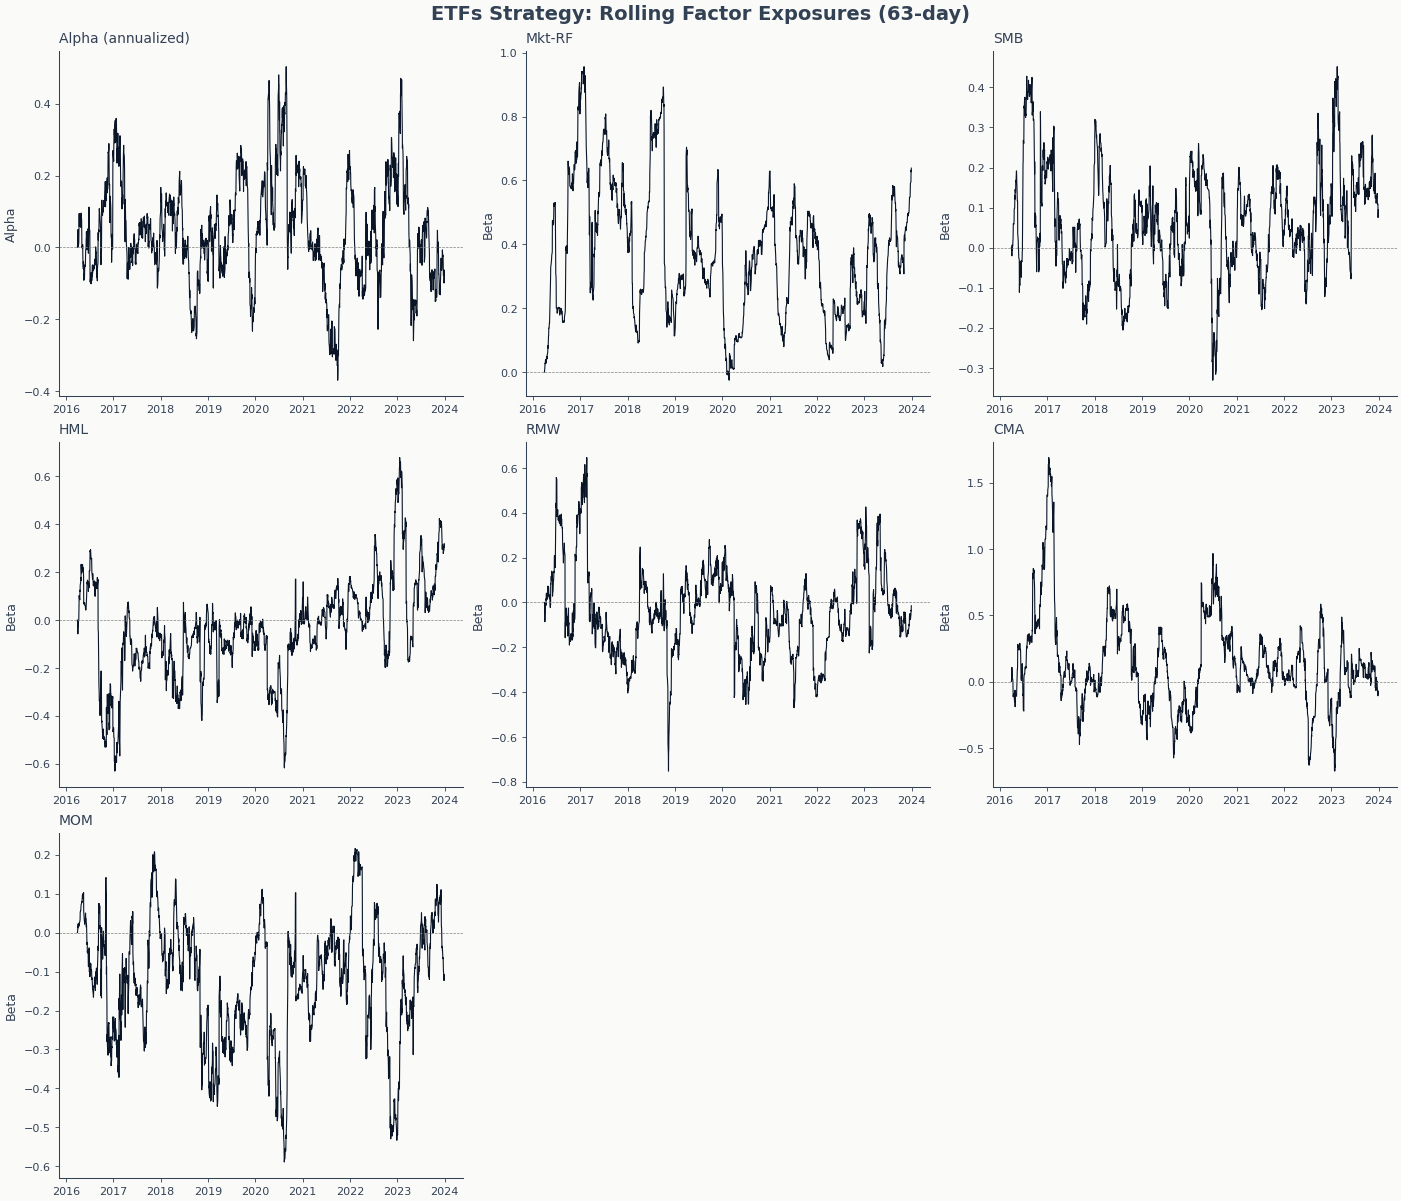

In [29]:
# Rolling factor exposures (63-day window ~ 3 months)
_rolling = compute_rolling_exposures(
    strat_returns_pd, _factors, model="ff5_mom", window=63, dollar_neutral=False
)
fig_roll = plot_rolling_exposures(
    _rolling, title="ETFs Strategy: Rolling Factor Exposures (63-day)"
)
fig_roll.show()

**Placebo benchmark (random ETF portfolios):**

In [30]:
from data import load_etfs as _load_etfs

_etf_data = _load_etfs()
_etf_daily = (
    _etf_data.sort("symbol", "timestamp")
    .with_columns(ret=pl.col("close").pct_change().over("symbol"))
    .drop_nulls("ret")
    .with_columns(date=pl.col("timestamp").dt.date())
    .group_by("symbol", "date")
    .agg(daily_ret=pl.col("ret").last())
    .sort("symbol", "date")
)
_etf_wide = (
    _etf_daily.pivot(on="symbol", index="date", values="daily_ret").to_pandas().set_index("date")
)
_etf_wide.index = pd.to_datetime(_etf_wide.index)

_placebo = run_placebo_benchmark(
    _etf_wide,
    _factors,
    n_sims=500,
    top_k=10,
    model="ff5_mom",
    dollar_neutral=False,
    seed=42,
)

if _placebo["n_sims"] > 0:
    print(f"""
=== Placebo Benchmark ({_placebo["n_sims"]} random long-only top-10 portfolios) ===
Random Mkt-RF beta: {_placebo["Mkt-RF_mean"]:+.3f} ± {_placebo["Mkt-RF_std"]:.3f}  [90% CI: {_placebo["Mkt-RF_p5"]:+.3f}, {_placebo["Mkt-RF_p95"]:+.3f}]
Random SMB beta:    {_placebo["SMB_mean"]:+.3f} ± {_placebo["SMB_std"]:.3f}
Random HML beta:    {_placebo["HML_mean"]:+.3f} ± {_placebo["HML_std"]:.3f}
Random alpha (ann): {_placebo["alpha_ann_mean"]:+.1%} ± {_placebo["alpha_ann_std"]:.1%}
Random R-squared:   {_placebo["r_squared_mean"]:.3f}
""")
    for factor in ("Mkt-RF", "SMB", "HML"):
        strat_beta = _reg["betas"].get(factor, 0)
        p5 = _placebo[f"{factor}_p5"]
        p95 = _placebo[f"{factor}_p95"]
        inside = "within" if p5 <= strat_beta <= p95 else "OUTSIDE"
        print(
            f"  Strategy {factor}: {strat_beta:+.3f} -- "
            f"{inside} random 90% CI [{p5:+.3f}, {p95:+.3f}]"
        )


=== Placebo Benchmark (500 random long-only top-10 portfolios) ===
Random Mkt-RF beta: +0.717 ± 0.113  [90% CI: +0.511, +0.885]
Random SMB beta:    +0.067 ± 0.074
Random HML beta:    +0.087 ± 0.086
Random alpha (ann): +0.0% ± 1.1%
Random R-squared:   0.854

  Strategy Mkt-RF: +0.229 -- OUTSIDE random 90% CI [+0.511, +0.885]
  Strategy SMB: +0.121 -- within random 90% CI [-0.036, +0.213]
  Strategy HML: -0.062 -- OUTSIDE random 90% CI [-0.038, +0.249]


In [31]:
# Block bootstrap CI on alpha and factor loadings
_boot = compute_bootstrap_ci(
    strat_returns_pd,
    _factors,
    model="ff5_mom",
    n_boot=1000,
    block_size=20,
    dollar_neutral=False,
    seed=42,
)
if _boot.get("n_boot", 0) > 0:
    print(
        f"=== Bootstrap CIs (n={_boot['n_boot']}, block=20 days) ===\n"
        f"Alpha (ann.) 95% CI: [{_boot['alpha_ann_lo']:+.1%}, {_boot['alpha_ann_hi']:+.1%}]"
    )
    for factor in _reg["factor_columns"]:
        key_lo = f"{factor}_lo"
        key_hi = f"{factor}_hi"
        if key_lo in _boot:
            print(f"  {factor:8s}: [{_boot[key_lo]:+.4f}, {_boot[key_hi]:+.4f}]")

=== Bootstrap CIs (n=1000, block=20 days) ===
Alpha (ann.) 95% CI: [+2.5%, +15.3%]
  Mkt-RF  : [+0.1486, +0.3485]
  SMB     : [+0.0590, +0.1756]
  HML     : [-0.1396, +0.0247]
  RMW     : [-0.1275, +0.0018]
  CMA     : [+0.0660, +0.2700]
  MOM     : [-0.1682, -0.0510]


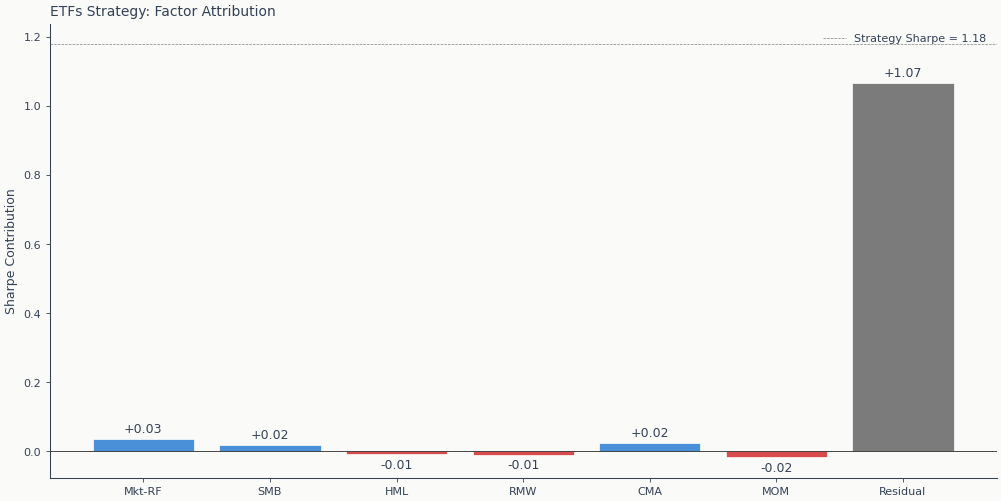

In [32]:
fig_attr = plot_attribution_waterfall(_reg, title="ETFs Strategy: Factor Attribution")
fig_attr.show()

Layer-1 placebo-regression alpha and Layer-2 FF5+MOM attribution
tell consistent stories. The cross-asset universe limits R² — bond,
commodity, and currency ETFs contribute returns largely orthogonal
to equity factors — so the residual Sharpe is a meaningful fraction
of the headline Sharpe, but the absolute alpha CI is wide enough
that "selection adds value over factor replication" cannot be
strongly resolved on the validation window alone. The placebo
benchmark confirms that random ETF portfolios show similarly modest
factor R² — the strategy's factor profile is partially
universe-driven rather than wholly selection-driven. AQR cross-asset
factors (TSMOM, value-everywhere, term-structure carry) would
provide a more complete attribution; that is a Ch20 cross-asset
extension rather than a per-CS deepening.

## §8 Strategy tear sheet

The diagnostic library renders the rank-1 lineage's full tear sheet
directly from the on-disk artifacts; we wire the validation-window
equal-weight ETF universe in as the benchmark series. The tear sheet
HTML is written under `OUTPUT_DIR` and is gitignored — readers
regenerate it locally.

In [33]:
backtest_dir = CASE_DIR / "run_log" / "backtest" / TOP_HASH
ho_dir = CASE_DIR / "run_log" / "backtest" / HO_HASH
print(f"Validation backtest_dir: {backtest_dir}")
print(f"  trades.parquet present: {(backtest_dir / 'trades.parquet').exists()}")
print(f"Holdout backtest_dir:    {ho_dir}")
print(f"  trades.parquet present: {(ho_dir / 'trades.parquet').exists()}")

# generate_tearsheet_from_run_artifacts wants a 1-D benchmark series,
# not a multi-column DataFrame.
bench_series = aligned["benchmark"].to_numpy()

meta = BacktestReportMetadata(
    title="ETFs — Rank-1 Lineage",
    strategy_name=f"{RANK1_FAMILY}/{RANK1_CONFIG} — {PRIMARY_LABEL}",
    universe=f"{setup['universe'].get('size', 100)} ETFs across categories",
    benchmark_name="ETF equal-weight universe (validation window)",
    evaluation_window=f"{aligned['ts'].min()} to {aligned['ts'].max()}",
    calendar=setup.get("evaluation", {}).get("calendar", "NYSE"),
)

tear_path = OUTPUT_DIR / f"{CASE_STUDY}_tearsheet.html"
html = generate_tearsheet_from_run_artifacts(
    backtest_dir,
    template="risk_manager",
    benchmark=bench_series,
    benchmark_name="EW universe (validation)",
    calendar=setup.get("evaluation", {}).get("calendar", "NYSE"),
    report_metadata=meta,
    output_path=str(tear_path),
)
print(f"Tear sheet written to: {tear_path}")
print(f"HTML size: {len(html):,} bytes")

Validation backtest_dir: case_studies/etfs/run_log/backtest/af67c54473fb
  trades.parquet present: True
Holdout backtest_dir:    case_studies/etfs/run_log/backtest/3441a76b7d13
  trades.parquet present: True


Tear sheet written to: 20_strategy_synthesis/output/etfs/etfs_tearsheet.html
HTML size: 1,103,956 bytes


## §9 Pre-Ch20 judgment & handoff

This section is the explicit hand-off point to Chapter 20. Numbers
below stay strictly inside the ETF case study — cross-case-study
comparison is Ch20's lane.

In [34]:
op_profile = compute_operating_profile(lineage, setup)
# ETFs setup uses `decision.cadence` rather than evaluation_protocol.
op_profile = op_profile.with_columns(
    pl.when(pl.col("property") == "Trading cadence")
    .then(pl.lit(setup["decision"]["cadence"]))
    .otherwise(pl.col("value"))
    .alias("value")
)
print("Operating profile (etfs, validation window):")
print(op_profile)
print()
print(
    f"Sharpe: {_fmt_ci(val_full['sharpe'], val_full['sharpe_ci95_lo'], val_full['sharpe_ci95_hi'])}"
)
print(f"Info ratio (vs EW val): {_fmt(getattr(metrics, 'information_ratio', None))}")
print(f"Max drawdown: {val_full['max_drawdown']:.3f}")

Operating profile (etfs, validation window):
shape: (5, 2)
┌─────────────────────────────────┬───────────────────┐
│ property                        ┆ value             │
│ ---                             ┆ ---               │
│ str                             ┆ str               │
╞═════════════════════════════════╪═══════════════════╡
│ Trading cadence                 ┆ monthly_month_end │
│ Portfolio concentration (top_k… ┆ 20                │
│ Allocator                       ┆ risk parity       │
│ Cost assumption                 ┆ —                 │
│ Worst drawdown                  ┆ -17.4%            │
└─────────────────────────────────┴───────────────────┘

Sharpe: 1.326 [0.708, 1.973]
Info ratio (vs EW val): 0.3576
Max drawdown: -0.110


In [35]:
gate1_status = gate1_validation_sharpe_geq_zero(val_full["sharpe_ci95_lo"])
_gate1_phrase = {
    "pass": "≥ 0 (passes)",
    "fail": "< 0 (fails)",
    "no_data": "CI unavailable",
}[gate1_status]
gate1_evidence = (
    f"Sharpe CI lower bound = {_fmt(val_full['sharpe_ci95_lo'], '.3f')} ({_gate1_phrase})"
)
gate2_ci_status = ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"])
gate2_status = gate2_holdout_diff_not_excludes_zero_negatively(gate2_ci_status, he["sharpe_diff"])
gate2_evidence = (
    f"Holdout strategy vs EW diff-Sharpe = "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])} "
    f"({gate2_ci_status})"
)

print("Kill-condition gates:")
print(f"  [{fmt_gate(gate1_status)}] Validation Sharpe CI lower bound ≥ 0:")
print(f"      {gate1_evidence}")
print(f"  [{fmt_gate(gate2_status)}] Holdout strategy CI does not exclude zero negatively:")
print(f"      {gate2_evidence}")

Kill-condition gates:
  [PASS] Validation Sharpe CI lower bound ≥ 0:
      Sharpe CI lower bound = 0.708 (≥ 0 (passes))
  [FAIL] Holdout strategy CI does not exclude zero negatively:
      Holdout strategy vs EW diff-Sharpe = -0.960 [-2.069, -0.023] (excludes_zero_strong)


**What this analysis does not say.** The validation window covers
2014–2023 (a decade dominated by US equity outperformance and a
falling-rate regime); the 2024–2025 holdout is a single
regime-different stretch where the equal-weight ETF universe ran
unusually hot (Sharpe 1.36) on broad equity strength. The wide val→ho
decay CI reflects that small-sample regime — a multi-year holdout
would resolve whether the rank-1's holdout underperformance vs EW is
regime-specific or persistent — but the point estimates (Sharpe
halving to 0.46, negative holdout IC, EW-relative CI excluding zero)
all point the same adverse direction, so this is a case where the
out-of-sample read does not confirm the validation edge. Selection-
adjusted cohort metrics (DSR, PBO, expected_max_sharpe) are not
populated for this lineage in the registry, so the in-sample guard
rests on the parametric PSR alone; the holdout closure above is the
decisive test. Capacity assumptions (the rank-1 trades 20 ETFs of the
100-ETF universe at monthly frequency) are not stress-tested at
scale — production sizing would need to model market impact on
less-liquid bond and commodity ETFs.

**Forward pointer to Ch20.** This case study contributes the
long-only / cross-asset-equity-anchored / monthly-cadence datapoint
to Ch20 nb01's rank-1-Sharpe + holdout-decay aggregation; the §6
strategy-vs-holdout-EW pair (sharpe_diff −0.960 [−2.069, −0.023],
excludes zero on the negative side) feeds Ch20 nb05's "did the
strategy beat its universe in the holdout window?" cross-CS panel.

In [36]:
search_ctx = ctx
assessment = {
    "case_study": CASE_STUDY,
    "primary_label": PRIMARY_LABEL,
    "spine_version": "v1",
    "rank1": {
        "family": RANK1_FAMILY,
        "config_name": RANK1_CONFIG,
        "label": PRIMARY_LABEL,
        "prediction_hash": TOP_PHASH,
        "validation_backtest_hash": TOP_HASH,
        "holdout_backtest_hash": HO_HASH,
    },
    "headline_performance": {
        "sharpe": {
            "point": val_full["sharpe"],
            "ci95_lo": val_full["sharpe_ci95_lo"],
            "ci95_hi": val_full["sharpe_ci95_hi"],
            "ci_status": sharpe_status,
        },
        "sortino": {
            "point": val_full["sortino"],
            "ci95_lo": val_full["sortino_ci95_lo"],
            "ci95_hi": val_full["sortino_ci95_hi"],
        },
        "ann_return": {
            "point": val_full["cagr"],
            "ci95_lo": val_full["ann_return_ci95_lo"],
            "ci95_hi": val_full["ann_return_ci95_hi"],
        },
        "max_drawdown": {
            "point": val_full["max_drawdown"],
            "ci95_lo": val_full["max_dd_ci95_lo"],
            "ci95_hi": val_full["max_dd_ci95_hi"],
        },
        "psr_pvalue": val_full["psr_pvalue"],
        "bootstrap_block_length": int(val_full["bootstrap_block_length"]),
        "bootstrap_n": int(val_full["bootstrap_n"]),
    },
    "selection_bias": {
        "k_variants": (
            int(val_full["k_variants"]) if val_full.get("k_variants") is not None else None
        ),
        "dsr": val_full.get("dsr"),
        "dsr_pvalue": val_full.get("dsr_pvalue"),
        "expected_max_sharpe": val_full.get("expected_max_sharpe"),
        "min_trl_periods": val_full.get("min_trl_periods"),
        "pbo": val_full.get("pbo"),
        "pbo_n_folds": (
            int(val_full["pbo_n_folds"]) if val_full.get("pbo_n_folds") is not None else None
        ),
        "pbo_n_combinations": (
            int(val_full["pbo_n_combinations"])
            if val_full.get("pbo_n_combinations") is not None
            else None
        ),
        "selection_adjustment_unavailable": val_full.get("dsr") is None,
    },
    "benchmark_relative": {
        "benchmark_name": "equal_weight_universe",
        "benchmark_validation_sharpe": ew_val["sharpe"],
        "benchmark_holdout_sharpe": ew_ho["sharpe"],
        "alpha_annualized_placebo": float(alpha_daily * PERIODS_PER_YEAR),
        "alpha_t_hac": float(alpha_t),
        "beta_to_ew": float(beta),
        "factor_attribution": format_attribution_summary(_reg, _boot),
    },
    "holdout_decay": {
        "val_hash": TOP_HASH,
        "holdout_hash": HO_HASH,
        "sharpe_diff": vh["sharpe_diff"],
        "sharpe_diff_ci95_lo": vh["sharpe_diff_ci95_lo"],
        "sharpe_diff_ci95_hi": vh["sharpe_diff_ci95_hi"],
        "sharpe_diff_p_value": vh["p_value"],
        "info_ratio": vh["info_ratio"],
        "decay_classification": ci_status(vh["sharpe_diff_ci95_lo"], vh["sharpe_diff_ci95_hi"]),
        "vs_ew_holdout": {
            "sharpe_diff": he["sharpe_diff"],
            "sharpe_diff_ci95_lo": he["sharpe_diff_ci95_lo"],
            "sharpe_diff_ci95_hi": he["sharpe_diff_ci95_hi"],
            "p_value": he["p_value"],
            "ci_status": ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"]),
        },
    },
    "search_context": {
        "total_signal_backtests": int(search_ctx["total"]),
        "median_sharpe": search_ctx["median_sharpe"],
        "p90_sharpe": search_ctx["p90_sharpe"],
        "pct_positive": search_ctx["pct_positive"],
    },
    "kill_gates": {
        "validation_sharpe_ci_lower_bound_geq_zero": gate_passes(gate1_status),
        "holdout_vs_ew_ci_does_not_exclude_zero_negatively": gate_passes(gate2_status),
    },
    "ch20_handoff": {
        "contributes_to": [
            "Ch20 nb01 — cross-CS rank-1 Sharpe and holdout-decay aggregation",
            "Ch20 nb05 — strategy-vs-universe holdout panel (long-only multi-asset datapoint)",
        ],
        "asset_class_label": "etfs_cross_asset",
        "rebalance_cadence": setup["decision"]["cadence"],
    },
}
assessment_path = write_strategy_assessment(CASE_STUDY, assessment)
print(f"strategy_assessment.json written to: {assessment_path}")

strategy_assessment.json written to: case_studies/etfs/results/strategy_assessment.json
